In [1]:
# Loading in data
import pandas as pd
import numpy as np
from openpyxl import load_workbook
import warnings
warnings.filterwarnings('ignore')

# Read the data
file_path = "./data/ARICS_DATA.xlsx"

data = pd.read_excel(file_path, sheet_name="COMBINED RAW DATASET")
print("File loaded successfully!")

# Clean column names
data.columns = data.columns.str.replace(' ', '_')
data.columns = data.columns.str.replace('%', 'Pct')
data.columns = data.columns.str.replace('[^a-zA-Z0-9_]', '')

# Rename columns with trailing underscores
data.columns = data.columns.str.replace('_+$', '', regex=True)  # Remove trailing underscores

# Print columns to verify
print("Columns after cleaning:")
print(data.columns.tolist())

File loaded successfully!
Columns after cleaning:
['SN', 'Section_Name', 'Road_No', 'Road_Name', 'CorridorRegion', 'Surface_Type', 'Road_Length', 'Network_Surveyed', 'GOOD', 'Pct_Good', 'FAIR', 'Pct_Fair', 'POOR', 'Pct_Poor', 'IRI', 'Remarks']


In [2]:
# Function to generate remarks based on % Good, % Fair, % Poor
def generate_remark(row):
    """
    Generate remark based on road condition percentages
    """
    good_pct = row.get('Pct_Good', np.nan)
    fair_pct = row.get('Pct_Fair', np.nan)
    poor_pct = row.get('Pct_Poor', np.nan)
    surface_type = row.get('Surface_Type', 'Unknown')
    
    # Convert to numeric
    try:
        good_pct = float(good_pct) if not pd.isna(good_pct) else np.nan
        fair_pct = float(fair_pct) if not pd.isna(fair_pct) else np.nan
        poor_pct = float(poor_pct) if not pd.isna(poor_pct) else np.nan
    except (ValueError, TypeError):
        return ""
    
    # Check for missing or invalid data
    if pd.isna(good_pct) or pd.isna(fair_pct) or pd.isna(poor_pct):
        return ""
    
    # If all are 0, no data
    if good_pct == 0 and fair_pct == 0 and poor_pct == 0:
        return ""
    
    # Special case: 100% Poor (completely impassable)
    if poor_pct == 1.0:
        return "Completely impassable"
    
    # Special case: Very poor condition (< 10% Good and > 80% Poor)
    if good_pct < 0.1 and poor_pct > 0.8:
        return "Completely impassable"
    
    # Determine condition based on % Good
    if good_pct >= 0.8:
        return "Excellent"
    elif good_pct >= 0.6:
        return "Fair. Need for improvement"
    elif good_pct >= 0.4:
        return "Poor. Requires rehabilitation"
    elif good_pct >= 0.2:
        return "Very poor. Major rehabilitation needed"
    else:
        return "Completely impassable"

# Apply the function
data['Remarks'] = data.apply(generate_remark, axis=1)

In [3]:
data.head()

,SN,Section_Name,Road_No,Road_Name,CorridorRegion,Surface_Type,Road_Length,Network_Surveyed,GOOD,Pct_Good,FAIR,Pct_Fair,POOR,Pct_Poor,IRI,Remarks
0,1.0,Nairobi Southern Bypass,S2,Southern Bypass,Corridor A,Paved,36.2,36.2,35.6,0.983425,0.2,0.005525,0.4,0.011050,1.050,Excellent
1,2.0,Nairobi Southern Bypass,S2_R,Southern Bypass,Corridor A,Paved,30.6,30.6,30.0,0.980392,0.2,0.006536,0.4,0.013072,1.085,Excellent
2,3.0,Athi River - Bisil,A2,Namanga - Athi River,Corridor A,Paved,42.3,42.3,38.3,0.905437,4.0,0.094563,0.0,0.000000,2.092,Excellent
3,4.0,Isinya - Bisil,A2,Namanga - Athi River,Corridor A,Paved,47.5,47.5,40.2,0.846316,2.3,0.048421,5.0,0.105263,2.259,Excellent
4,5.0,Bisil - Namanga,A2,Namanga - Athi River,Corridor A,Paved,61.4,61.4,58.4,0.951140,1.8,0.029316,1.2,0.019544,2.068,Excellent


In [4]:
def generate_detailed_remark(row):
    """
    Generate detailed remark with condition and percentages
    """
    good_pct = row.get('Pct_Good', np.nan)
    fair_pct = row.get('Pct_Fair', np.nan)
    poor_pct = row.get('Pct_Poor', np.nan)
    surface_type = row.get('Surface_Type', 'Unknown')
    
    try:
        good_pct = float(good_pct) if not pd.isna(good_pct) else np.nan
        fair_pct = float(fair_pct) if not pd.isna(fair_pct) else np.nan
        poor_pct = float(poor_pct) if not pd.isna(poor_pct) else np.nan
    except (ValueError, TypeError):
        return ""
    
    if pd.isna(good_pct) or pd.isna(fair_pct) or pd.isna(poor_pct):
        return ""
    
    if good_pct == 0 and fair_pct == 0 and poor_pct == 0:
        return ""
    
    # Get base remark
    base_remark = generate_remark(row)
    
    if base_remark == "":
        return ""
    
    # Format with percentages
    if base_remark == "Completely impassable":
        return f"{base_remark} ({surface_type}, Good: {good_pct*100:.0f}%, Fair: {fair_pct*100:.0f}%, Poor: {poor_pct*100:.0f}%)"
    else:
        return f"{base_remark} ({surface_type}, Good: {good_pct*100:.0f}%, Fair: {fair_pct*100:.0f}%, Poor: {poor_pct*100:.0f}%)"

data['Detailed_Remarks'] = data.apply(generate_detailed_remark, axis=1)


In [5]:
data.head()

,SN,Section_Name,Road_No,Road_Name,CorridorRegion,Surface_Type,Road_Length,Network_Surveyed,GOOD,Pct_Good,FAIR,Pct_Fair,POOR,Pct_Poor,IRI,Remarks,Detailed_Remarks
0,1.0,Nairobi Southern Bypass,S2,Southern Bypass,Corridor A,Paved,36.2,36.2,35.6,0.983425,0.2,0.005525,0.4,0.011050,1.050,Excellent,"Excellent (Paved, Good: 98%, Fair: 1%, Poor: 1%)"
1,2.0,Nairobi Southern Bypass,S2_R,Southern Bypass,Corridor A,Paved,30.6,30.6,30.0,0.980392,0.2,0.006536,0.4,0.013072,1.085,Excellent,"Excellent (Paved, Good: 98%, Fair: 1%, Poor: 1%)"
2,3.0,Athi River - Bisil,A2,Namanga - Athi River,Corridor A,Paved,42.3,42.3,38.3,0.905437,4.0,0.094563,0.0,0.000000,2.092,Excellent,"Excellent (Paved, Good: 91%, Fair: 9%, Poor: 0%)"
3,4.0,Isinya - Bisil,A2,Namanga - Athi River,Corridor A,Paved,47.5,47.5,40.2,0.846316,2.3,0.048421,5.0,0.105263,2.259,Excellent,"Excellent (Paved, Good: 85%, Fair: 5%, Poor: 11%)"
4,5.0,Bisil - Namanga,A2,Namanga - Athi River,Corridor A,Paved,61.4,61.4,58.4,0.951140,1.8,0.029316,1.2,0.019544,2.068,Excellent,"Excellent (Paved, Good: 95%, Fair: 3%, Poor: 2%)"


In [6]:
# Create summary
remark_summary = data['Remarks'].value_counts().reset_index()
remark_summary.columns = ['Remarks', 'Count']
remark_summary

,Remarks,Count
0,Completely impassable,164
1,Excellent,153
2,Fair. Need for improvement,53
3,Very poor. Major rehabilitation needed,41
4,Poor. Requires rehabilitation,37
5,,25


In [7]:
# Condition by surface type
condition_surface = data.groupby(['Remarks', 'Surface_Type']).size().reset_index(name='Count')
condition_surface['pct'] = condition_surface.groupby('Surface_Type')['Count'].transform(
    lambda x: (x / x.sum()) * 100
)
condition_surface

,Remarks,Surface_Type,Count,pct
0,,Paved,9,2.990033
1,,Unpaved,16,9.302326
2,Completely impassable,Paved,61,20.265781
3,Completely impassable,Unpaved,103,59.883721
4,Excellent,Paved,143,47.508306
5,Excellent,Unpaved,10,5.813953
6,Fair. Need for improvement,Paved,45,14.950166
7,Fair. Need for improvement,Unpaved,8,4.651163
8,Poor. Requires rehabilitation,Paved,25,8.305648
9,Poor. Requires rehabilitation,Unpaved,12,6.976744


In [8]:
pivot_pct = pd.DataFrame({
    'Completely impassable': {'Paved': 24.5, 'Unpaved': 56.9},
    'Excellent': {'Paved': 57.4, 'Unpaved': 5.5},
    'Fair: Need for improvement': {'Paved': 18.1, 'Unpaved': 4.4},
    'Poor: Requires rehabilitation': {'Paved': 10.0, 'Unpaved': 6.6},
    'Very poor: Major rehabilitation needed': {'Paved': 7.2, 'Unpaved': 12.7}
})

# Reorder columns for better visualization
condition_order = ['Excellent', 'Fair: Need for improvement', 
                   'Poor: Requires rehabilitation', 
                   'Very poor: Major rehabilitation needed', 
                   'Completely impassable']
pivot_pct = pivot_pct[condition_order]

print("Percentage Distribution Data:")
print(pivot_pct)

Percentage Distribution Data:
         Excellent  Fair: Need for improvement  Poor: Requires rehabilitation  \
Paved         57.4                        18.1                           10.0   
Unpaved        5.5                         4.4                            6.6   

         Very poor: Major rehabilitation needed  Completely impassable  
Paved                                       7.2                   24.5  
Unpaved                                    12.7                   56.9  


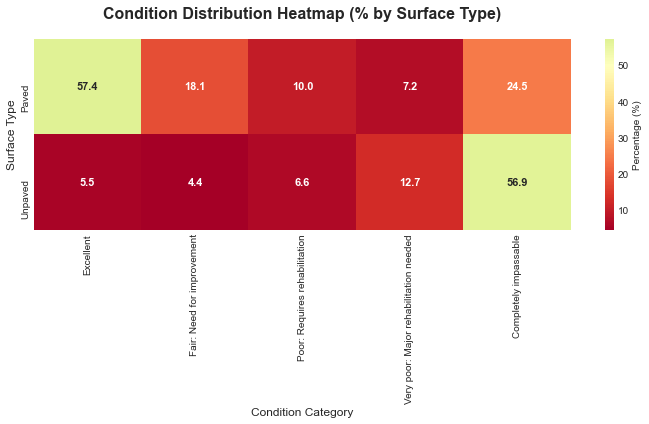

In [9]:
# Create heatmap data (percentages)
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
sns.set_palette("Set2")


fig6, ax6 = plt.subplots(figsize=(10, 6))
heatmap_data = pivot_pct

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, ax=ax6, cbar_kws={'label': 'Percentage (%)'},
            annot_kws={'size': 11, 'weight': 'bold'})

ax6.set_title('Condition Distribution Heatmap (% by Surface Type)', 
             fontsize=16, fontweight='bold', pad=20)
ax6.set_xlabel('Condition Category', fontsize=12)
ax6.set_ylabel('Surface Type', fontsize=12)

plt.tight_layout()
plt.savefig('Condition_Heatmap.png', dpi=300, bbox_inches='tight');

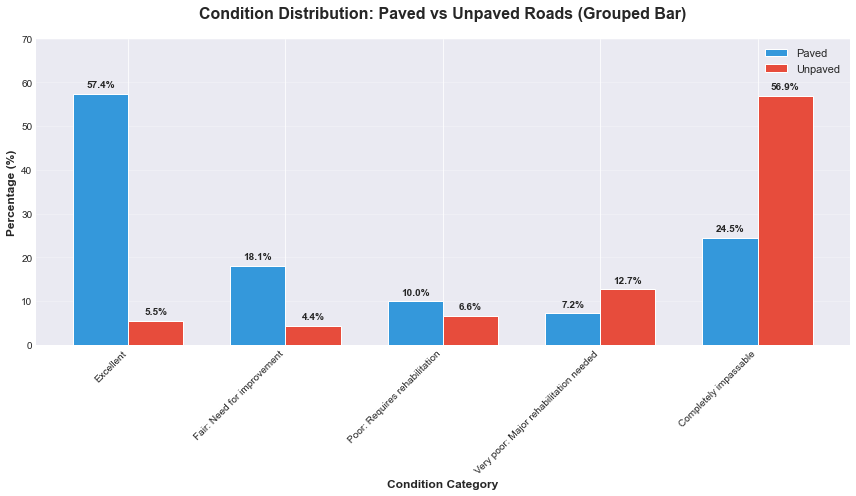

In [10]:
# Your pivot_pct data (from the heatmap)
pivot_pct = pd.DataFrame({
    'Excellent': {'Paved': 57.4, 'Unpaved': 5.5},
    'Fair: Need for improvement': {'Paved': 18.1, 'Unpaved': 4.4},
    'Poor: Requires rehabilitation': {'Paved': 10.0, 'Unpaved': 6.6},
    'Very poor: Major rehabilitation needed': {'Paved': 7.2, 'Unpaved': 12.7},
    'Completely impassable': {'Paved': 24.5, 'Unpaved': 56.9}
})

# Grouped Bar Chart
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Prepare data for grouped bars
conditions = pivot_pct.columns
x = np.arange(len(conditions))
width = 0.35

paved_values = pivot_pct.loc['Paved'].values
unpaved_values = pivot_pct.loc['Unpaved'].values

# Create bars
bars1 = ax1.bar(x - width/2, paved_values, width, label='Paved', 
                color='#3498db', edgecolor='white', linewidth=1)
bars2 = ax1.bar(x + width/2, unpaved_values, width, label='Unpaved', 
                color='#e74c3c', edgecolor='white', linewidth=1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', 
                    fontsize=10, fontweight='bold')

# Customize
ax1.set_xlabel('Condition Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('Condition Distribution: Paved vs Unpaved Roads (Grouped Bar)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(conditions, rotation=45, ha='right')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 70)

plt.tight_layout()
plt.savefig('Condition_Bar_Chart.png', dpi=300, bbox_inches='tight');